# Phishing URL Detection using Multiple Machine Learning Models


**Project aim:** classify URLs as **legitimate** (`0`) or **phishing** (`1`) using numerical URL-structure features.

**Notebook flow:**
1. Import libraries and set a clean plotting theme
2. Load the dataset from Google Drive
3. Inspect the data
4. Remove duplicate rows
5. Focused EDA with clean plots
6. Correlation heatmap with values
7. Train/test split
8. Train four machine learning models
9. Compare model performance
10. Tune Gradient Boosting
11. Evaluate the final model




## 1. Import libraries and set configuration

In [1]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Core libraries
from pathlib import Path
import json

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Save model
import joblib

# Reproducibility
RANDOM_STATE = 42

# Target column
TARGET = "phishing"

# Output folders
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Class labels
CLASS_LABELS = {
    0: "Legitimate",
    1: "Phishing"
}

# Consistent colours used across all plots
TEAL = "#2A9D8F"
CORAL = "#E76F51"
BLUE = "#457B9D"
PURPLE = "#7B2CBF"
GOLD = "#E9C46A"
DARK = "#264653"
GREY = "#6C757D"

CLASS_PALETTE = {
    "Legitimate": TEAL,
    "Phishing": CORAL
}

MODEL_COLORS = [TEAL, CORAL, BLUE, PURPLE, GOLD, GREY]

# Plot theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#EAEAEA"
})

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 2. Helper functions for plots

These helper functions keep the plotting style consistent throughout the notebook.

In [2]:
def finish_plot(save_name=None):
    """Apply final formatting, save the figure, and display it."""
    sns.despine()
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIGURE_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def add_vertical_bar_labels(ax, fmt="{:.1f}", suffix="", fontsize=9):
    """Add labels above vertical bars."""
    for container in ax.containers:
        labels = [f"{fmt.format(value)}{suffix}" for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=fontsize, weight="bold")


def add_horizontal_bar_labels(ax, values, fmt="{:.3f}", suffix="", fontsize=9):
    """Add labels at the end of horizontal bars."""
    for i, value in enumerate(values):
        ax.text(
            value,
            i,
            f" {fmt.format(value)}{suffix}",
            va="center",
            ha="left",
            fontsize=fontsize,
            weight="bold",
            color=DARK
        )


def compact_grouped_bar_plot(plot_pivot, title, ylabel, save_name):
    """
    Create a compact grouped bar chart using the same style as the preferred class-balance plot.
    plot_pivot must have stages as rows and classes as columns.
    """
    x = np.arange(len(plot_pivot.index))
    bar_width = 0.24
    bar_gap = 0.04

    fig, ax = plt.subplots(figsize=(6.4, 3.9))

    bars_left = ax.bar(
        x - (bar_width / 2 + bar_gap / 2),
        plot_pivot.iloc[:, 0],
        width=bar_width,
        label=plot_pivot.columns[0],
        color=CLASS_PALETTE.get(plot_pivot.columns[0], TEAL),
        edgecolor="white",
        linewidth=0.8
    )

    bars_right = ax.bar(
        x + (bar_width / 2 + bar_gap / 2),
        plot_pivot.iloc[:, 1],
        width=bar_width,
        label=plot_pivot.columns[1],
        color=CLASS_PALETTE.get(plot_pivot.columns[1], CORAL),
        edgecolor="white",
        linewidth=0.8
    )

    ax.set_title(title, pad=10, weight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_pivot.index, fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.35)

    return fig, ax, [bars_left, bars_right]

## 3. Load the dataset from Google Drive only

Save the dataset in Google Drive at:

```text
/content/drive/MyDrive/web-page-phishing.csv
```

In [3]:
# Load dataset from Google Drive only

from pathlib import Path
import pandas as pd

# Mount Google Drive when running in Google Colab
from google.colab import drive
drive.mount("/content/drive")

# Google Drive dataset path
DATA_PATH = Path("/content/drive/MyDrive/web-page-phishing.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Please upload web-page-phishing.csv directly to MyDrive, then run this cell again."
    )

# Read dataset
df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset path: {DATA_PATH}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")

display(df_raw.head(10))

Mounted at /content/drive
Dataset loaded successfully.
Dataset path: /content/drive/MyDrive/web-page-phishing.csv
Rows: 100,077
Columns: 20


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,32,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
6,19,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7,81,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
8,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,104,1,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Basic data checks

This section checks the dataset structure, target column, missing values, and duplicates.

In [4]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDataset information:")
df_raw.info()

Column names:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection', 'phishing']

Data types:


,dtype
url_length,int64
n_dots,int64
n_hypens,int64
n_underline,int64
n_slash,int64
n_questionmark,int64
n_equal,int64
n_at,int64
n_and,int64
n_exclamation,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100077 entries, 0 to 100076
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   url_length      100077 non-null  int64
 1   n_dots          100077 non-null  int64
 2   n_hypens        100077 non-null  int64
 3   n_underline     100077 non-null  int64
 4   n_slash         100077 non-null  int64
 5   n_questionmark  100077 non-null  int64
 6   n_equal         100077 non-null  int64
 7   n_at            100077 non-null  int64
 8   n_and           100077 non-null  int64
 9   n_exclamation   100077 non-null  int64
 10  n_space         100077 non-null  int64
 11  n_tilde         100077 non-null  int64
 12  n_comma         100077 non-null  int64
 13  n_plus          100077 non-null  int64
 14  n_asterisk      100077 non-null  int64
 15  n_hastag        100077 non-null  int64
 16  n_dollar        100077 non-null  int64
 17  n_percent       100077 non

In [5]:
# Validate target column
if TARGET not in df_raw.columns:
    raise ValueError(f"Target column '{TARGET}' was not found in the dataset.")

# Validate target values
target_values = sorted(df_raw[TARGET].dropna().unique().tolist())
print(f"Target values found: {target_values}")

if not set(target_values).issubset({0, 1}):
    raise ValueError("Target column should contain only 0 and 1 values.")

# Feature columns
feature_cols = [col for col in df_raw.columns if col != TARGET]
print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

Target values found: [0, 1]
Number of features: 19
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection']


In [6]:
# Missing values summary
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percentage": (df_raw.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

missing_summary.to_csv(TABLE_DIR / "missing_values_summary.csv")
display(missing_summary)

,missing_count,missing_percentage
url_length,0,0.0
n_dots,0,0.0
n_hypens,0,0.0
n_underline,0,0.0
n_slash,0,0.0
n_questionmark,0,0.0
n_equal,0,0.0
n_at,0,0.0
n_and,0,0.0
n_exclamation,0,0.0


## 5. Remove duplicate rows

Duplicate rows are removed before model training.

In [7]:
# Duplicate summary before removal
exact_duplicate_count = df_raw.duplicated().sum()
exact_duplicate_percentage = exact_duplicate_count / len(df_raw) * 100

print(f"Exact duplicate rows before removal: {exact_duplicate_count:,}")
print(f"Exact duplicate percentage before removal: {exact_duplicate_percentage:.2f}%")

# Remove duplicates
before_rows = len(df_raw)
df = df_raw.drop_duplicates().reset_index(drop=True)
after_rows = len(df)
removed_rows = before_rows - after_rows

print(f"Rows before duplicate removal: {before_rows:,}")
print(f"Rows after duplicate removal: {after_rows:,}")
print(f"Rows removed: {removed_rows:,}")

# Save duplicate summary
duplicate_summary = pd.DataFrame({
    "metric": ["rows_before", "rows_after", "duplicate_rows_removed", "duplicate_percentage"],
    "value": [before_rows, after_rows, removed_rows, round(exact_duplicate_percentage, 2)]
})
duplicate_summary.to_csv(TABLE_DIR / "duplicate_summary.csv", index=False)
display(duplicate_summary)

Exact duplicate rows before removal: 78,186
Exact duplicate percentage before removal: 78.13%
Rows before duplicate removal: 100,077
Rows after duplicate removal: 21,891
Rows removed: 78,186


,metric,value
0,rows_before,100077.00
1,rows_after,21891.00
2,duplicate_rows_removed,78186.00
3,duplicate_percentage,78.13


In [8]:
# Class balance before and after duplicate removal
before_counts = (
    df_raw[TARGET]
    .map(CLASS_LABELS)
    .value_counts()
    .reindex(["Legitimate", "Phishing"])
)

after_counts = (
    df[TARGET]
    .map(CLASS_LABELS)
    .value_counts()
    .reindex(["Legitimate", "Phishing"])
)

class_effect = pd.DataFrame({
    "Before duplicate removal": before_counts,
    "After duplicate removal": after_counts
})

class_effect["Before percentage"] = (class_effect["Before duplicate removal"] / before_counts.sum() * 100).round(2)
class_effect["After percentage"] = (class_effect["After duplicate removal"] / after_counts.sum() * 100).round(2)

class_effect.to_csv(TABLE_DIR / "class_balance_before_after_duplicate_removal.csv")
display(class_effect)

,Before duplicate removal,After duplicate removal,Before percentage,After percentage
phishing,,,,
Legitimate,63715,6019,63.67,27.5
Phishing,36362,15872,36.33,72.5


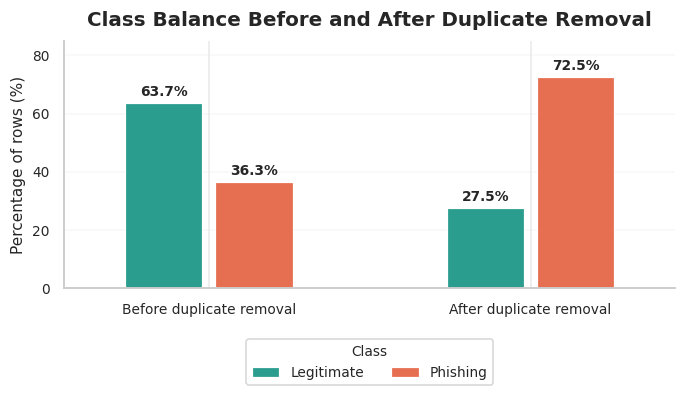

In [9]:
# Compact class-balance plot using percentages
plot_pivot = pd.DataFrame({
    "Legitimate": [
        class_effect.loc["Legitimate", "Before percentage"],
        class_effect.loc["Legitimate", "After percentage"]
    ],
    "Phishing": [
        class_effect.loc["Phishing", "Before percentage"],
        class_effect.loc["Phishing", "After percentage"]
    ]
}, index=["Before duplicate removal", "After duplicate removal"])

fig, ax, bar_groups = compact_grouped_bar_plot(
    plot_pivot=plot_pivot,
    title="Class Balance Before and After Duplicate Removal",
    ylabel="Percentage of rows (%)",
    save_name="class_balance_before_after_duplicates_percentage.png"
)

ax.set_ylim(0, 85)
ax.set_xlim(-0.45, len(plot_pivot.index) - 0.55)

for bars in bar_groups:
    ax.bar_label(
        bars,
        labels=[f"{bar.get_height():.1f}%" for bar in bars],
        padding=3,
        fontsize=9,
        weight="bold"
    )

ax.legend(
    title="Class",
    frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=9,
    title_fontsize=9
)

finish_plot("class_balance_before_after_duplicates_percentage.png")

## 6. Focused EDA after duplicate removal

The following EDA uses the duplicate-removed dataset.

In [10]:
# Class distribution after duplicate removal
class_distribution = df[TARGET].map(CLASS_LABELS).value_counts().reindex(["Legitimate", "Phishing"]).to_frame("count")
class_distribution["percentage"] = (class_distribution["count"] / len(df) * 100).round(2)

class_distribution.to_csv(TABLE_DIR / "class_distribution_after_duplicate_removal.csv")
display(class_distribution)

,count,percentage
phishing,,
Legitimate,6019,27.5
Phishing,15872,72.5


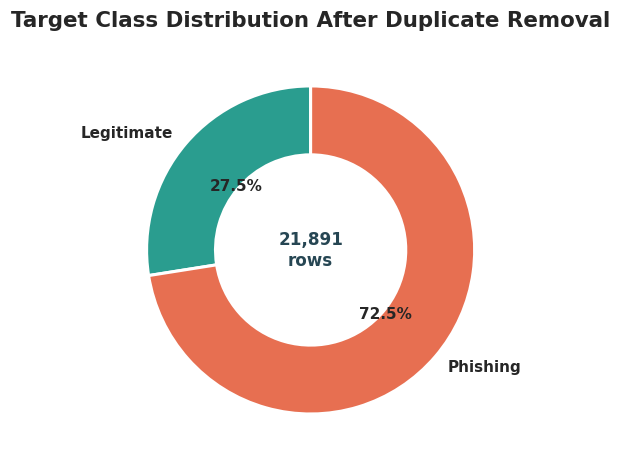

In [11]:
# Donut chart for class distribution after duplicate removal
fig, ax = plt.subplots(figsize=(5.6, 4.4))

wedges, texts, autotexts = ax.pie(
    class_distribution["count"],
    labels=class_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[CLASS_PALETTE["Legitimate"], CLASS_PALETTE["Phishing"]],
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10, "weight": "bold"}
)

ax.set_title("Target Class Distribution After Duplicate Removal", pad=12, weight="bold")
ax.text(0, 0, f"{len(df):,}\nrows", ha="center", va="center", fontsize=11, weight="bold", color=DARK)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution_after_duplicate_removal_donut.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Descriptive statistics for numeric features
summary_stats = df[feature_cols].describe().T
summary_stats.to_csv(TABLE_DIR / "descriptive_statistics_after_duplicate_removal.csv")
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
url_length,21891.0,78.476086,77.361414,4.0,41.0,61.0,88.0,4165.0
n_dots,21891.0,2.894066,2.161135,1.0,2.0,2.0,3.0,24.0
n_hypens,21891.0,1.308072,2.351815,0.0,0.0,1.0,2.0,43.0
n_underline,21891.0,0.482481,1.385397,0.0,0.0,0.0,0.0,21.0
n_slash,21891.0,2.569184,2.451018,0.0,0.0,2.0,4.0,44.0
n_questionmark,21891.0,0.083642,0.304815,0.0,0.0,0.0,0.0,9.0
n_equal,21891.0,0.710886,1.720661,0.0,0.0,0.0,1.0,23.0
n_at,21891.0,0.083824,0.554197,0.0,0.0,0.0,0.0,43.0
n_and,21891.0,0.492074,1.741748,0.0,0.0,0.0,0.0,26.0
n_exclamation,21891.0,0.009456,0.168437,0.0,0.0,0.0,0.0,10.0


In [13]:
# Class-wise mean comparison
class_means = df.groupby(TARGET)[feature_cols].mean().T
class_means.columns = ["mean_legitimate", "mean_phishing"]
class_means["absolute_difference"] = (class_means["mean_phishing"] - class_means["mean_legitimate"]).abs()
class_means["phishing_minus_legitimate"] = class_means["mean_phishing"] - class_means["mean_legitimate"]
class_means = class_means.sort_values("absolute_difference", ascending=False)

class_means.to_csv(TABLE_DIR / "class_wise_feature_means.csv")
display(class_means.head(10))

,mean_legitimate,mean_phishing,absolute_difference,phishing_minus_legitimate
url_length,52.288254,88.407069,36.118815,36.118815
n_slash,1.218641,3.081338,1.862697,1.862697
n_hypens,1.835022,1.108241,0.726782,-0.726782
n_equal,0.193886,0.906943,0.713057,0.713057
n_dots,2.399568,3.081590,0.682022,0.682022
n_and,0.094700,0.642767,0.548067,0.548067
n_redirection,0.673700,0.372669,0.301031,-0.301031
n_underline,0.371823,0.524446,0.152623,0.152623
n_at,0.000332,0.115486,0.115154,0.115154
n_percent,0.444924,0.361013,0.083911,-0.083911


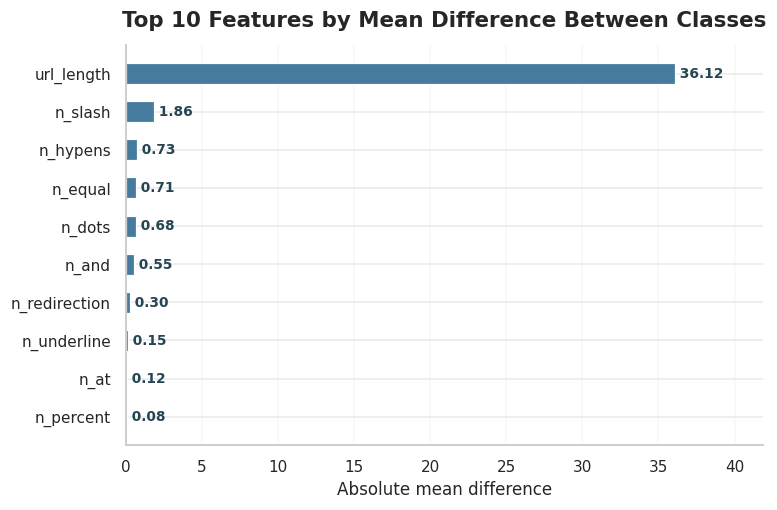

In [14]:
# Horizontal bar plot: top feature mean differences
plot_data = class_means.head(10).sort_values("absolute_difference")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.barh(
    plot_data.index,
    plot_data["absolute_difference"],
    color=BLUE,
    edgecolor="white",
    linewidth=0.8,
    height=0.55
)

ax.set_title("Top 10 Features by Mean Difference Between Classes", pad=12, weight="bold")
ax.set_xlabel("Absolute mean difference")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.35)
add_horizontal_bar_labels(ax, plot_data["absolute_difference"].values, fmt="{:.2f}", fontsize=9)
ax.set_xlim(0, plot_data["absolute_difference"].max() * 1.16)
finish_plot("top_feature_mean_differences.png")

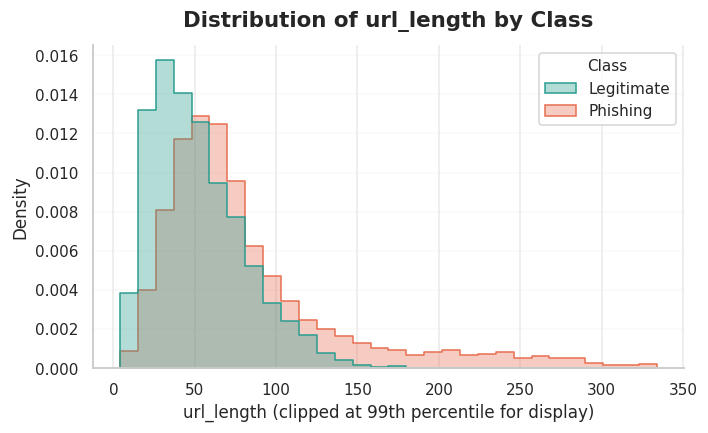

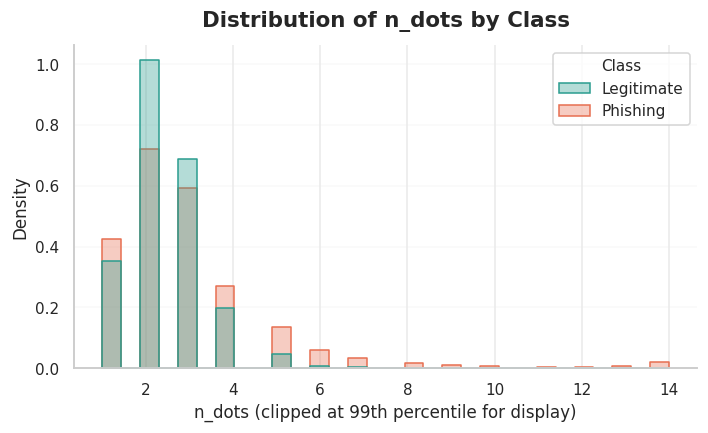

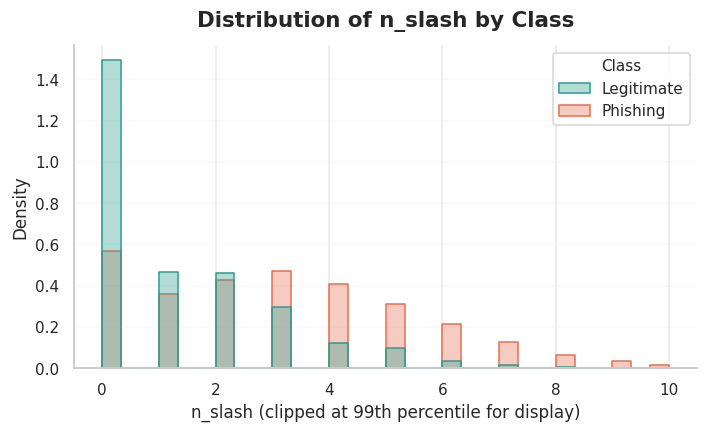

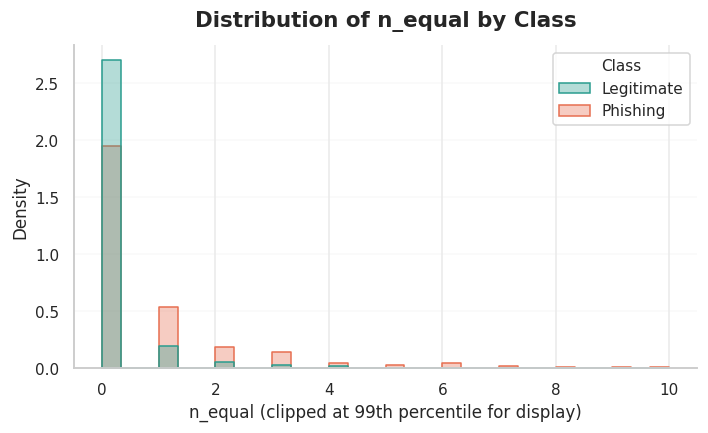

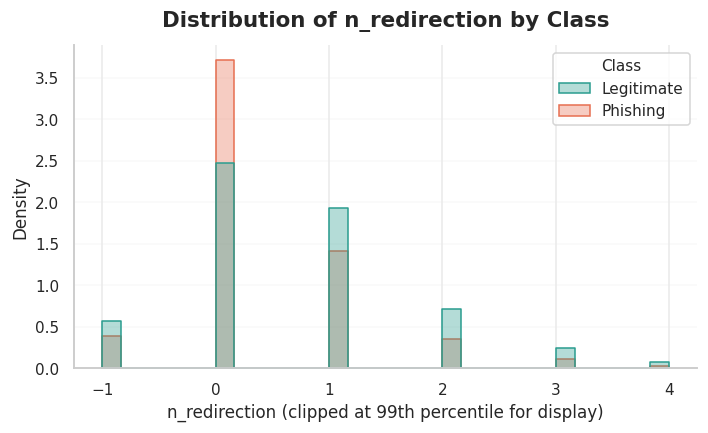

In [15]:
# Selected feature distributions
# The x-axis is clipped at the 99th percentile for display only, because URL features are highly skewed.
selected_distribution_features = [
    "url_length",
    "n_dots",
    "n_slash",
    "n_equal",
    "n_redirection"
]

selected_distribution_features = [col for col in selected_distribution_features if col in df.columns]
plot_df = df.copy()
plot_df["Class"] = plot_df[TARGET].map(CLASS_LABELS)

for feature in selected_distribution_features:
    upper_limit = plot_df[feature].quantile(0.99)
    filtered_plot_df = plot_df[plot_df[feature] <= upper_limit]

    fig, ax = plt.subplots(figsize=(6.6, 4.1))
    sns.histplot(
        data=filtered_plot_df,
        x=feature,
        hue="Class",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.35,
        palette=CLASS_PALETTE,
        ax=ax
    )

    ax.set_title(f"Distribution of {feature} by Class", pad=12, weight="bold")
    ax.set_xlabel(f"{feature} (clipped at 99th percentile for display)")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.30)
    finish_plot(f"distribution_{feature}_by_class.png")

## 7. Correlation analysis

The heatmap below uses the ten features most correlated with the target.


In [16]:
# Full correlation matrix
corr_matrix_full = df[feature_cols + [TARGET]].corr(numeric_only=True)
corr_matrix_full.to_csv(TABLE_DIR / "full_correlation_matrix.csv")

# Correlation of each feature with the phishing target
correlation_with_target = corr_matrix_full[TARGET].drop(TARGET).to_frame("correlation_with_phishing")
correlation_with_target["absolute_correlation"] = correlation_with_target["correlation_with_phishing"].abs()
correlation_with_target = correlation_with_target.sort_values("absolute_correlation", ascending=False)

correlation_with_target.to_csv(TABLE_DIR / "feature_target_correlations.csv")
display(correlation_with_target)

,correlation_with_phishing,absolute_correlation
n_slash,0.339327,0.339327
url_length,0.208464,0.208464
n_equal,0.185034,0.185034
n_redirection,-0.142559,0.142559
n_dots,0.140909,0.140909
n_and,0.140498,0.140498
n_hypens,-0.137982,0.137982
n_questionmark,0.112592,0.112592
n_at,0.092776,0.092776
n_underline,0.049189,0.049189


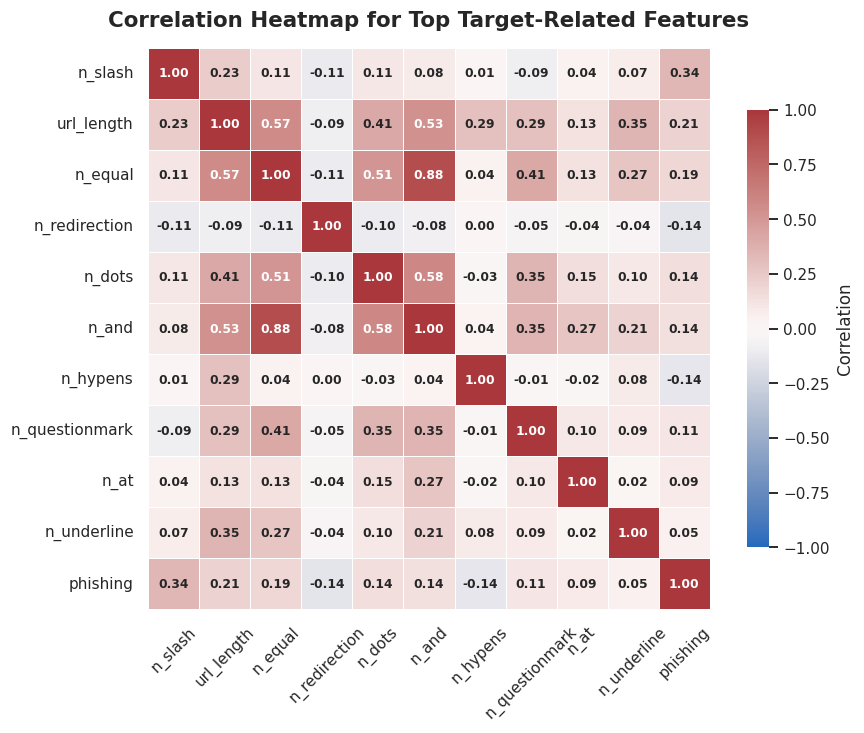

In [17]:
# Correlation heatmap with values
# Top 10 features are used to keep the heatmap readable.
top_corr_features = correlation_with_target.head(10).index.tolist()
heatmap_cols = top_corr_features + [TARGET]
corr_matrix = df[heatmap_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8.4, 6.8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.78, "label": "Correlation"},
    annot_kws={"fontsize": 8, "weight": "bold"},
    ax=ax
)

ax.set_title("Correlation Heatmap for Top Target-Related Features", pad=14, weight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_feature_correlation_heatmap_with_values.png", dpi=300, bbox_inches="tight")
plt.show()

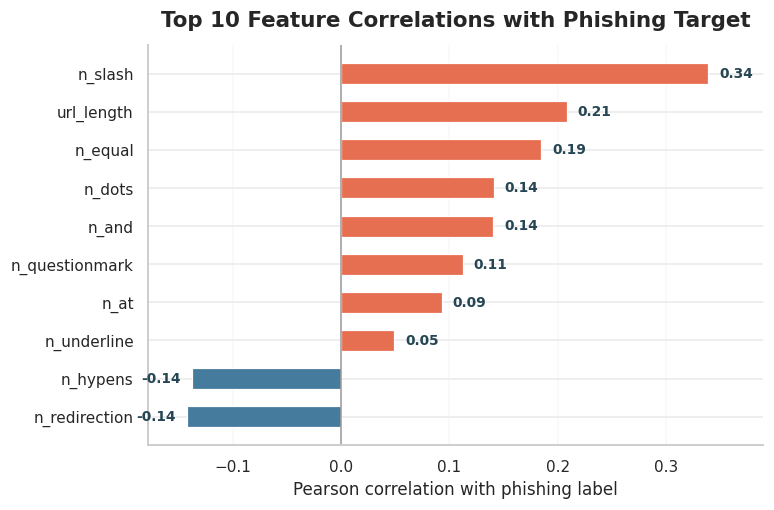

In [18]:
# Horizontal bar plot: top correlations with the phishing target
plot_data = correlation_with_target.head(10).sort_values("correlation_with_phishing")
bar_colors = [CORAL if value > 0 else BLUE for value in plot_data["correlation_with_phishing"]]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.barh(
    plot_data.index,
    plot_data["correlation_with_phishing"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    height=0.55
)

ax.axvline(0, color="#999999", linewidth=1)
ax.set_title("Top 10 Feature Correlations with Phishing Target", pad=12, weight="bold")
ax.set_xlabel("Pearson correlation with phishing label")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.35)

for i, value in enumerate(plot_data["correlation_with_phishing"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.01 if value >= 0 else -0.01
    ax.text(value + offset, i, f"{value:.2f}", va="center", ha=ha, fontsize=9, weight="bold", color=DARK)

x_min = min(plot_data["correlation_with_phishing"].min() * 1.25, -0.08)
x_max = max(plot_data["correlation_with_phishing"].max() * 1.15, 0.08)
ax.set_xlim(x_min, x_max)
finish_plot("top_target_correlations.png")

## 8. Prepare data for modelling

The duplicate-removed dataset is used for model training. A stratified train/test split keeps the class ratio similar in both sets.

In [19]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

train_distribution = y_train.map(CLASS_LABELS).value_counts(normalize=True).reindex(["Legitimate", "Phishing"]).to_frame("train_percentage")
test_distribution = y_test.map(CLASS_LABELS).value_counts(normalize=True).reindex(["Legitimate", "Phishing"]).to_frame("test_percentage")

split_distribution = pd.concat([train_distribution, test_distribution], axis=1).round(4)
split_distribution.to_csv(TABLE_DIR / "train_test_class_distribution.csv")
display(split_distribution)

Training features shape: (17512, 19)
Testing features shape: (4379, 19)


,train_percentage,test_percentage
phishing,,
Legitimate,0.275,0.2749
Phishing,0.725,0.7251


## 9. Evaluation helper functions

In [20]:
def get_model_scores(model, X_test_data):
    """Return score values for ROC-AUC and precision-recall metrics."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_test_data)
    return model.predict(X_test_data)


def evaluate_classifier(model, X_test_data, y_test_data, model_name):
    """Evaluate a binary classifier using several metrics."""
    y_pred = model.predict(X_test_data)
    y_score = get_model_scores(model, X_test_data)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_data, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_data, y_score),
        "Average Precision": average_precision_score(y_test_data, y_score)
    }


def plot_confusion_matrix_with_values(model, X_test_data, y_test_data, title, save_name=None):
    """Plot a clean confusion matrix with values inside the cells."""
    y_pred = model.predict(X_test_data)
    cm = confusion_matrix(y_test_data, y_pred)

    fig, ax = plt.subplots(figsize=(5.4, 4.4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="crest",
        linewidths=1,
        linecolor="white",
        cbar=False,
        square=True,
        annot_kws={"fontsize": 12, "weight": "bold"},
        ax=ax
    )

    ax.set_title(title, pad=12, weight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(["Legitimate", "Phishing"], rotation=0)
    ax.set_yticklabels(["Legitimate", "Phishing"], rotation=0)

    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIGURE_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()
    return cm

## 10. Train four models

Four models are trained:

1. Logistic Regression
2. Linear Support Vector Machine
3. Random Forest
4. Gradient Boosting

Scaling is used inside pipelines for Logistic Regression and SVM because they are sensitive to feature scale. Tree-based models do not require scaling.

In [21]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE))
    ]),

    "Linear SVM": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    model_results.append(evaluate_classifier(model, X_test, y_test, model_name))

model_results_df = pd.DataFrame(model_results).sort_values("F1 Score", ascending=False)
model_results_df.to_csv(TABLE_DIR / "four_model_comparison_results.csv", index=False)

display(model_results_df)

Training Logistic Regression...
Training Linear SVM...
Training Random Forest...
Training Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
3,Gradient Boosting,0.813656,0.836904,0.922835,0.877771,0.872373,0.949150
2,Random Forest,0.743549,0.814724,0.836535,0.825486,0.811812,0.922356
0,Logistic Regression,0.739667,0.913450,0.708031,0.797729,0.835132,0.936430
1,Linear SVM,0.730532,0.914761,0.692913,0.788530,0.834391,0.936079


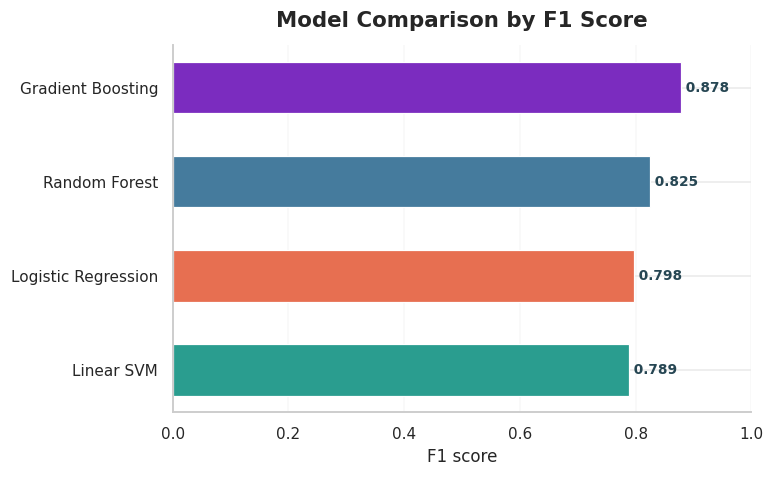

In [22]:
# Horizontal bar plot: model comparison by F1 score
plot_data = model_results_df.sort_values("F1 Score")
colors = MODEL_COLORS[:len(plot_data)]

fig, ax = plt.subplots(figsize=(7.2, 4.5))
bars = ax.barh(
    plot_data["Model"],
    plot_data["F1 Score"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    height=0.55
)

ax.set_title("Model Comparison by F1 Score", pad=12, weight="bold")
ax.set_xlabel("F1 score")
ax.set_ylabel("")
ax.set_xlim(0, 1.0)
ax.grid(axis="x", alpha=0.35)
add_horizontal_bar_labels(ax, plot_data["F1 Score"].values, fmt="{:.3f}", fontsize=9)
finish_plot("model_comparison_f1_score.png")

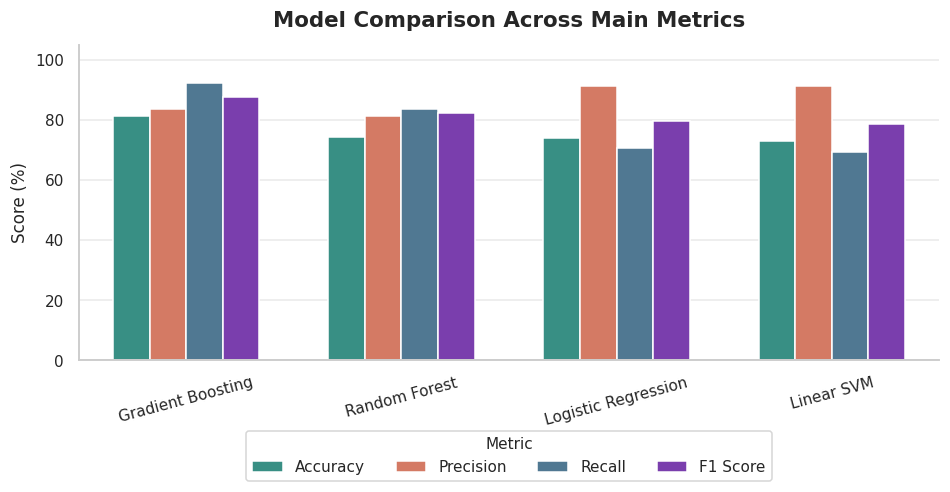

In [23]:
# grouped bar plot: main metrics for all models
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_plot_df = model_results_df[["Model"] + metric_cols].copy()
metric_plot_df[metric_cols] = metric_plot_df[metric_cols] * 100
metric_plot_long = metric_plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(8.8, 4.8))
sns.barplot(
    data=metric_plot_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[TEAL, CORAL, BLUE, PURPLE],
    width=0.68,
    ax=ax
)

ax.set_title("Model Comparison Across Main Metrics", pad=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric", frameon=True, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=4)
finish_plot("model_comparison_main_metrics.png")

## 11. Hyperparameter trials for Gradient Boosting

A small validation-based search is used to keep the code simple and easy to explain. The best trial is selected using validation F1 score.

In [24]:
# Split the training data into inner training and validation sets for tuning
X_inner_train, X_valid, y_inner_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

parameter_trials = [
    {"n_estimators": 80, "learning_rate": 0.10, "max_depth": 2, "subsample": 1.0},
    {"n_estimators": 100, "learning_rate": 0.10, "max_depth": 3, "subsample": 1.0},
    {"n_estimators": 120, "learning_rate": 0.05, "max_depth": 3, "subsample": 1.0},
    {"n_estimators": 120, "learning_rate": 0.10, "max_depth": 3, "subsample": 0.8}
]
trial_results = []

for i, params in enumerate(parameter_trials, start=1):
    model = GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **params
    )
    model.fit(X_inner_train, y_inner_train)

    result = evaluate_classifier(model, X_valid, y_valid, f"Trial {i}")
    result.update(params)
    trial_results.append(result)

    print(f"Completed Trial {i}: {params} | F1 = {result['F1 Score']:.4f}")

trial_results_df = pd.DataFrame(trial_results).sort_values("F1 Score", ascending=False)
trial_results_df.to_csv(TABLE_DIR / "gradient_boosting_hyperparameter_trials.csv", index=False)

display(trial_results_df)

Completed Trial 1: {'n_estimators': 80, 'learning_rate': 0.1, 'max_depth': 2, 'subsample': 1.0} | F1 = 0.8692
Completed Trial 2: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0} | F1 = 0.8775
Completed Trial 3: {'n_estimators': 120, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0} | F1 = 0.8752
Completed Trial 4: {'n_estimators': 120, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8} | F1 = 0.8787


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,n_estimators,learning_rate,max_depth,subsample
3,Trial 4,0.817299,0.846969,0.912992,0.878742,0.877873,0.951505,120,0.10,3,0.8
1,Trial 2,0.814445,0.841896,0.916142,0.877451,0.874608,0.950212,100,0.10,3,1.0
2,Trial 3,0.809592,0.834106,0.920472,0.875164,0.869270,0.947698,120,0.05,3,1.0
0,Trial 1,0.799886,0.825948,0.917323,0.869241,0.859732,0.943736,80,0.10,2,1.0


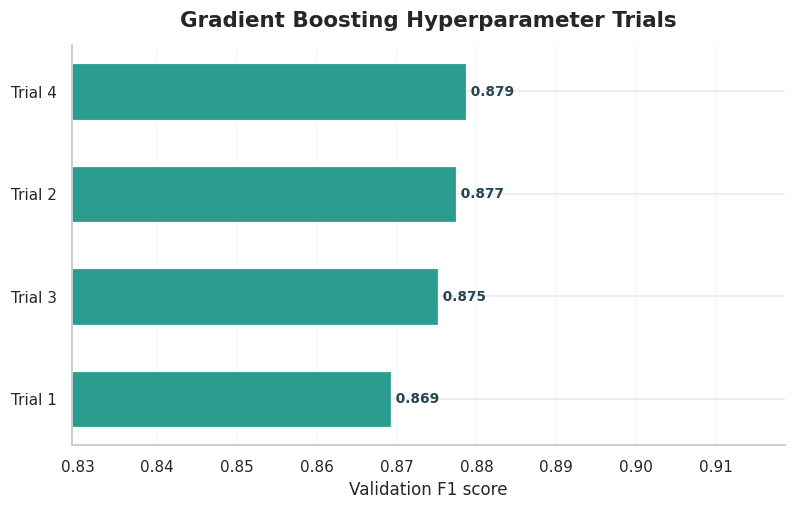

In [25]:
# Horizontal bar plot: hyperparameter trials by validation F1 score
plot_data = trial_results_df.sort_values("F1 Score")

fig, ax = plt.subplots(figsize=(7.4, 4.8))
bars = ax.barh(
    plot_data["Model"],
    plot_data["F1 Score"],
    color=TEAL,
    edgecolor="white",
    linewidth=0.8,
    height=0.55
)

ax.set_title("Gradient Boosting Hyperparameter Trials", pad=12, weight="bold")
ax.set_xlabel("Validation F1 score")
ax.set_ylabel("")
ax.set_xlim(max(0, plot_data["F1 Score"].min() - 0.04), min(1, plot_data["F1 Score"].max() + 0.04))
ax.grid(axis="x", alpha=0.35)
add_horizontal_bar_labels(ax, plot_data["F1 Score"].values, fmt="{:.3f}", fontsize=9)
finish_plot("gradient_boosting_hyperparameter_trials.png")

In [26]:
# Select best hyperparameters using validation F1 score
best_trial = trial_results_df.iloc[0]

best_params = {
    "n_estimators": int(best_trial["n_estimators"]),
    "learning_rate": float(best_trial["learning_rate"]),
    "max_depth": int(best_trial["max_depth"]),
    "subsample": float(best_trial["subsample"])
}

print("Best hyperparameters:")
print(best_params)

with open(MODEL_DIR / "best_gradient_boosting_hyperparameters.json", "w") as f:
    json.dump(best_params, f, indent=4)

Best hyperparameters:
{'n_estimators': 120, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}


## 12. Train and evaluate the final model

The final model is trained using the best Gradient Boosting hyperparameters. The test set is used only for final evaluation.

In [27]:
final_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    **best_params
)

final_model.fit(X_train, y_train)

final_result = evaluate_classifier(final_model, X_test, y_test, "Final Tuned Gradient Boosting")
final_result_df = pd.DataFrame([final_result])
final_result_df.to_csv(TABLE_DIR / "final_tuned_gradient_boosting_result.csv", index=False)

display(final_result_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Final Tuned Gradient Boosting,0.810687,0.838235,0.915591,0.875207,0.87459,0.950214


In [28]:
# Combine main model results and final tuned result
all_results = pd.concat(
    [model_results_df, final_result_df],
    ignore_index=True
).sort_values("F1 Score", ascending=False)

all_results.to_csv(TABLE_DIR / "all_model_results.csv", index=False)
display(all_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Gradient Boosting,0.813656,0.836904,0.922835,0.877771,0.872373,0.949150
4,Final Tuned Gradient Boosting,0.810687,0.838235,0.915591,0.875207,0.874590,0.950214
1,Random Forest,0.743549,0.814724,0.836535,0.825486,0.811812,0.922356
2,Logistic Regression,0.739667,0.913450,0.708031,0.797729,0.835132,0.936430
3,Linear SVM,0.730532,0.914761,0.692913,0.788530,0.834391,0.936079


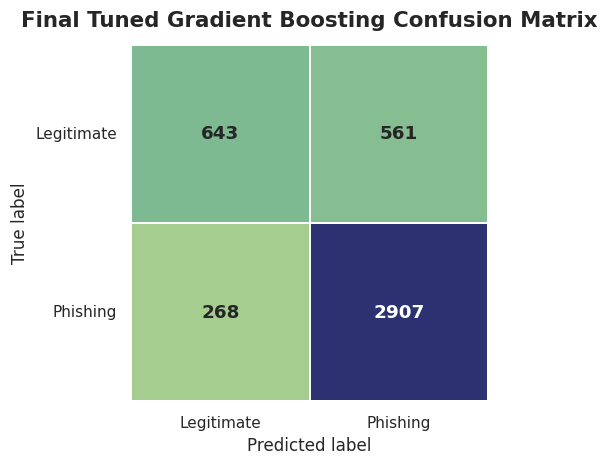

,Predicted Legitimate,Predicted Phishing
Actual Legitimate,643,561
Actual Phishing,268,2907


In [29]:
# Confusion matrix with values
final_cm = plot_confusion_matrix_with_values(
    final_model,
    X_test,
    y_test,
    title="Final Tuned Gradient Boosting Confusion Matrix",
    save_name="final_tuned_gradient_boosting_confusion_matrix.png"
)

final_cm_df = pd.DataFrame(
    final_cm,
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)

final_cm_df.to_csv(TABLE_DIR / "final_tuned_gradient_boosting_confusion_matrix.csv")
display(final_cm_df)

In [30]:
# Classification report
final_predictions = final_model.predict(X_test)
final_scores = final_model.predict_proba(X_test)[:, 1]

report = classification_report(
    y_test,
    final_predictions,
    target_names=["Legitimate", "Phishing"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.to_csv(TABLE_DIR / "final_tuned_gradient_boosting_classification_report.csv")
display(report_df)

,precision,recall,f1-score,support
Legitimate,0.705818,0.534053,0.608038,1204.000000
Phishing,0.838235,0.915591,0.875207,3175.000000
accuracy,0.810687,0.810687,0.810687,0.810687
macro avg,0.772027,0.724822,0.741622,4379.000000
weighted avg,0.801827,0.810687,0.801749,4379.000000


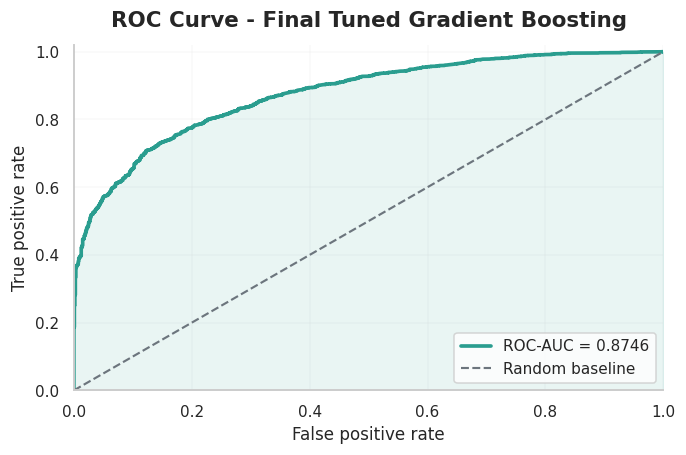

In [31]:
# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, final_scores)
roc_auc = roc_auc_score(y_test, final_scores)

fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.plot(fpr, tpr, color=TEAL, linewidth=2.4, label=f"ROC-AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.4, label="Random baseline")
ax.fill_between(fpr, tpr, alpha=0.10, color=TEAL)

ax.set_title("ROC Curve - Final Tuned Gradient Boosting", pad=12, weight="bold")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=True, loc="lower right")
ax.grid(alpha=0.30)
finish_plot("final_tuned_gradient_boosting_roc_curve.png")

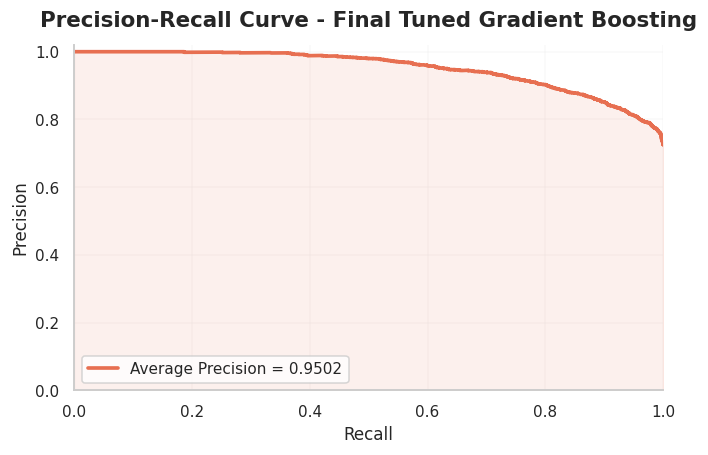

In [32]:
# precision-recall curve
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, final_scores)
average_precision = average_precision_score(y_test, final_scores)

fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.plot(recall_values, precision_values, color=CORAL, linewidth=2.4, label=f"Average Precision = {average_precision:.4f}")
ax.fill_between(recall_values, precision_values, alpha=0.10, color=CORAL)

ax.set_title("Precision-Recall Curve - Final Tuned Gradient Boosting", pad=12, weight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=True, loc="lower left")
ax.grid(alpha=0.30)
finish_plot("final_tuned_gradient_boosting_precision_recall_curve.png")

,feature,importance
4,n_slash,0.328359
0,url_length,0.224604
2,n_hypens,0.149588
1,n_dots,0.075666
6,n_equal,0.068732
3,n_underline,0.033189
5,n_questionmark,0.032297
18,n_redirection,0.029788
7,n_at,0.022745
17,n_percent,0.014235


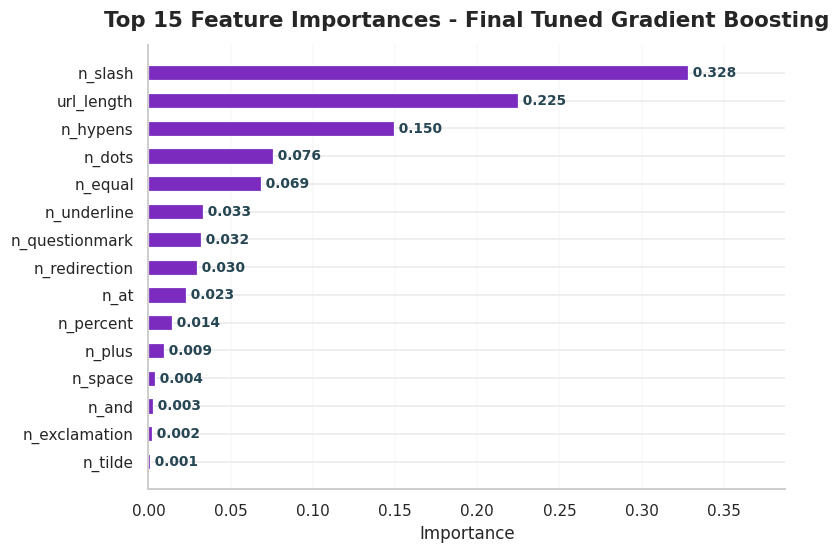

In [33]:
# Feature importance for final Gradient Boosting model
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv(TABLE_DIR / "final_tuned_gradient_boosting_feature_importance.csv", index=False)
display(feature_importance.head(15))

plot_data = feature_importance.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(7.4, 5.2))
bars = ax.barh(
    plot_data["feature"],
    plot_data["importance"],
    color=PURPLE,
    edgecolor="white",
    linewidth=0.8,
    height=0.55
)

ax.set_title("Top 15 Feature Importances - Final Tuned Gradient Boosting", pad=12, weight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.35)
add_horizontal_bar_labels(ax, plot_data["importance"].values, fmt="{:.3f}", fontsize=9)
ax.set_xlim(0, plot_data["importance"].max() * 1.18)
finish_plot("final_tuned_gradient_boosting_feature_importance.png")

## 13. Save the final model

In [34]:
# Save final model bundle for reuse
model_bundle = {
    "model": final_model,
    "feature_columns": feature_cols,
    "target_column": TARGET,
    "best_hyperparameters": best_params,
    "class_mapping": CLASS_LABELS
}

model_path = MODEL_DIR / "final_gradient_boosting_phishing_model.joblib"
joblib.dump(model_bundle, model_path)

print(f"Final model saved to: {model_path}")

Final model saved to: outputs/models/final_gradient_boosting_phishing_model.joblib
